# 1. Data Import and Initial Exploration

IMPORTED NECESSARY LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score



import warnings;
warnings.filterwarnings('ignore');

LOADED DATASETS

In [2]:
sentiment_df = pd.read_csv(r"C:\Users\Santhoshi\Downloads\fear_greed_index.csv")
trader_df = pd.read_csv(r"C:\Users\Santhoshi\Downloads\historical_data.csv")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# To display full length of columns used set_option function 

In [4]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
# Data Overview of Trader Dataset

print('Trader Dataset Shape:', trader_df.shape)
print('-'*50)
print('\nData Types:')
print(trader_df.info())
print('-'*50)
print('\nDuplicate Values:', trader_df.duplicated().sum())

Trader Dataset Shape: (211224, 16)
--------------------------------------------------

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID         

In [7]:
# Data Overview of Sentiment Dataset

print('Sentiment Dataset Shape:', sentiment_df.shape)
print('-'*50)
print('\nData Types:')
print(sentiment_df.info())
print('-'*50)
print('\nDuplicate Values:', sentiment_df.duplicated().sum())

Sentiment Dataset Shape: (2644, 4)
--------------------------------------------------

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
--------------------------------------------------

Duplicate Values: 0


#

### 1.1 Correcting the data types of the columns

In [8]:
# Convert Timestamp to datetime
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst = True)
trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])

# converted Trade ID from float to int because float Ids can cause precision issues
trader_df['Trade ID'] = trader_df['Trade ID'].astype('int64')

In [9]:
sentiment_df['timestamp'] = pd.to_datetime(sentiment_df['timestamp'], unit = 's')
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

#

### 1.2 Merging Datasets

In [10]:
# preparing tarder data to merge the datasets based on timestamp common column between both the datasets

trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst = True).dt.date

In [11]:
# Here forcing into same datatype

trader_df['date'] = pd.to_datetime(trader_df['date']).dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

In [12]:
# Merging both datasets

merged_df = trader_df.merge(sentiment_df, on = 'date', how = 'left')
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,895000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,443000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,660000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1080000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1050000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed


#

### 1.3 Check for null values on merged dataset

In [13]:
# checking for null values

merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
timestamp           6
value               6
classification      6
dtype: int64

In [14]:
# dropping null values

merged_df = merged_df.dropna()

In [15]:
merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
timestamp           0
value               0
classification      0
dtype: int64

#

## 2. Metrics Calculation

### 2.1 Daily PnL per trader per account

In [16]:
# for accurate profit fee was deducted from pnl and calculated net PnL

merged_df['Net_PnL'] = merged_df['Closed PnL'] - merged_df['Fee']

# To ensure a realistic evaluation of trader profitability, I computed net PnL by accounting for transaction costs, as fees can significantly impact trading outcomes, especially for high-frequency 
# traders.

In [17]:
daily_pnl_per_trader = merged_df.groupby(['Account', 'date'])['Net_PnL'].sum().reset_index()

In [18]:
daily_pnl_per_trader

,Account,date,Net_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,-167.796055
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,-67.883615
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,-94.937983
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21260.823995
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1498.477510
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1683.554931
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,3849.038668
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8212.850393
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2500.458579


#

## 2.2 Win Rate

#### 2.2.1 Win Rate Per Trader

In [19]:
win_ratio = merged_df.groupby('Account')['Net_PnL'].apply(lambda x: (x > 0).mean()).reset_index(name = 'win_ratio')
win_ratio

,Account,win_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.440385
2,0x271b280974205ca63b716753467d5a371de622ab,0.280389
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.434152
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.518061
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.312883
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.327668
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.475904
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236


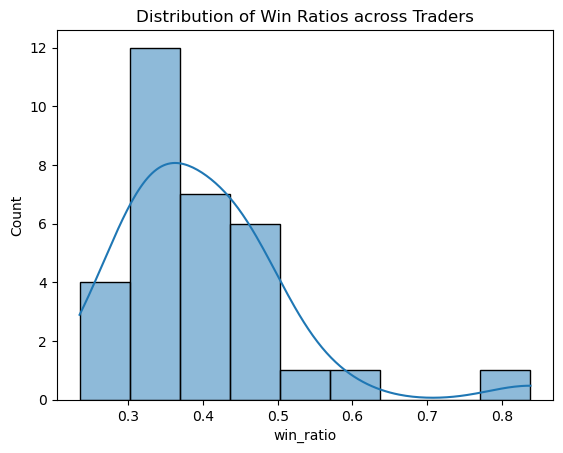

In [20]:
sns.histplot(win_ratio['win_ratio'], kde=True)
plt.title('Distribution of Win Ratios across Traders')
plt.show()

#

#### Observation 1:
Most traders are not consistently profitable
- From Win ratio Per Trader:
  - Majority of traders have win ratio between 0.30 - 0.45
  - Very few cross 0.50


#### Insights:
Most traders exhibit win ratios below 50%, indicating that they incur losses more frequently than gains. This suggests that profitability in this market is difficult to sustain and requires strong strategy or risk management.


 
#### Observation 2:
A small group of highly consistent trader exsists
   - One trader has 0.83 win ratio
   - Few above 0.55


#### Insight:
A small subset of traders demonstrates significantly higher win ratios (above 60–80%), indicating the presence of highly consistent performers who likely follow disciplined strategies or effective risk management techniques.

#

### 2.2 Win Ratio Per Sentiment

In [21]:
win_ratio_sentiment = merged_df.groupby(['classification'])['Net_PnL'].apply(lambda x: (x>0).mean()).reset_index(name = 'win_ratio')
win_ratio_sentiment

,classification,win_ratio
0,Extreme Fear,0.368458
1,Extreme Greed,0.467694
2,Fear,0.411517
3,Greed,0.391249
4,Neutral,0.395903


#

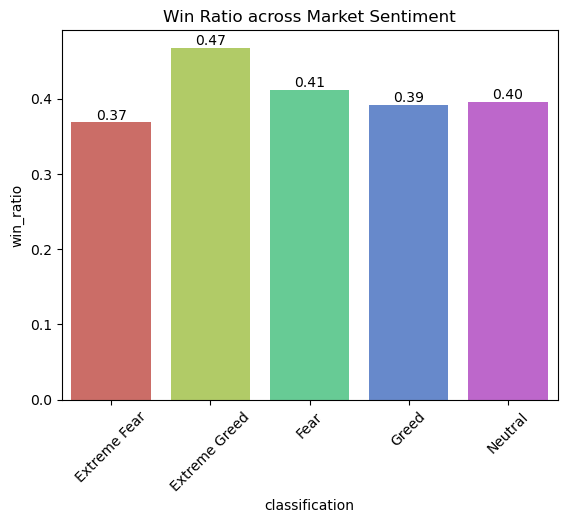

In [22]:
ax = sns.barplot(data = win_ratio_sentiment, x ='classification', y ='win_ratio', palette = 'hls')

for i in ax.containers:
    ax.bar_label(i, fmt = '%.2f')

plt.title('Win Ratio across Market Sentiment')
plt.xticks(rotation=45)
plt.show()

#### Observation1:
- Best Performance - Extreme Greed
- Worst performance - Extreme Fear
- But normal Greed is NOT best - interesting 


#### Insight:
Trader performance varies across sentiment regimes, with the highest win ratio observed during Extreme Greed and the lowest during Extreme Fear. This suggests that traders perform better in strongly bullish conditions, while high uncertainty or panic negatively impacts decision-making and profitability.


#### Observation2:
Greed does not always mean better performance
Extreme greed > greed


#### Insight:
normal Greed conditions do not yield the highest win rates, while Extreme Greed does. This indicates that strong directional trends (extreme optimism) may provide clearer trading opportunities compared to moderately positive sentiment.

#

### 2.3 Daily Win Rate

In [23]:
daily_win = merged_df.groupby(['Account','date'])['Net_PnL'].apply(lambda x: (x > 0).mean()).reset_index(name = 'win_ratio')
daily_win

,Account,date,win_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,0.390244
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,0.393023
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,0.441242
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,0.506667


#

#### Observation 1:

- From Daily Win rate
 Some trader :
    - Some days -> 0.0
    - Some days -> 0.5+
Trader performance is highly inconsistent day-to-day


#### Insight:
Daily win ratios show high variability for individual traders, with performance fluctuating significantly across days. This highlights the short-term unpredictability of trading outcomes and suggests that consistent profitability requires long-term strategy rather than reliance on daily performance.

#### Observation 2:
- From Daily data:
    - Many rows = 0.0 win ratio
 
#### Insight:
Number of trading days result in zero win ratios, indicating that traders often experience complete losing sessions. This results in high-risk nature of trading, particularly under uncertain market conditions.

#

### Insight:
The variation in win ratios across both traders and sentiment regimes suggests that performance is influenced not only by market conditions but also by individual trading behavior. Skilled traders are likely better at adapting strategies to different sentiment environments


### Recommendation:
Traders should adopt conservative strategies during Extreme Fear periods and capitalize on strong trends during Extreme Greed phases to improve overall performance

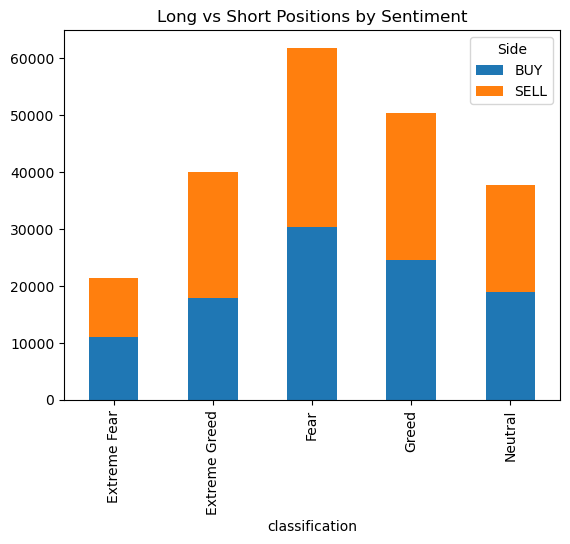

In [26]:
side_data = merged_df.groupby(['classification','Side']).size().unstack()
side_data.plot(kind='bar', stacked=True)
plt.title('Long vs Short Positions by Sentiment')
plt.show()

#

#

## 3. Average Trade Size

In [27]:
avg_trade_size = merged_df.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


#

### 4. Number of Trades Per day

In [28]:
trades_per_day = merged_df.groupby(['date','Account']).size()
trades_per_day

date        Account                                   
2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891      3
2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23      9
2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     11
2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23      2
2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23      3
                                                         ... 
2025-05-01  0xa0feb3725a9335f49874d7cd8eaad6be45b27416    288
            0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     73
            0xbaaaf6571ab7d571043ff1e313a9609a10637864      1
            0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    116
            0xbee1707d6b44d4d52bfe19e41f8a828645437aab    131
Length: 2340, dtype: int64

#

### 5. Long/Short ratio

In [29]:
merged_df['Side'].value_counts(normalize = True)

Side
SELL    0.51382
BUY     0.48618
Name: proportion, dtype: float64

#

### 6. Leverage Distribution

Since explicit leverage data was not available, trade size (USD) was used as a proxy to approximate leverage behavior. Larger trade sizes indicate higher exposure and potential leverage usage.

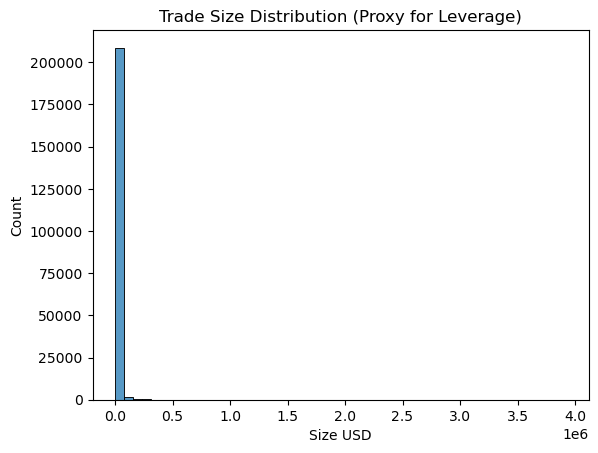

In [30]:
sns.histplot(merged_df['Size USD'], bins=50)
plt.title('Trade Size Distribution (Proxy for Leverage)')
plt.show()

#

#### Observation :
- The trade size distribution is heavily right-skewed, indicating that the majority of trades are small, while a small number of trades are extremely larges, indicating  the presence of high-risk or high-leverage trading behavior.

So Applied log scale on skewed distribution, this spread the data properly, show actual distribution, reveal patterns clearly

#

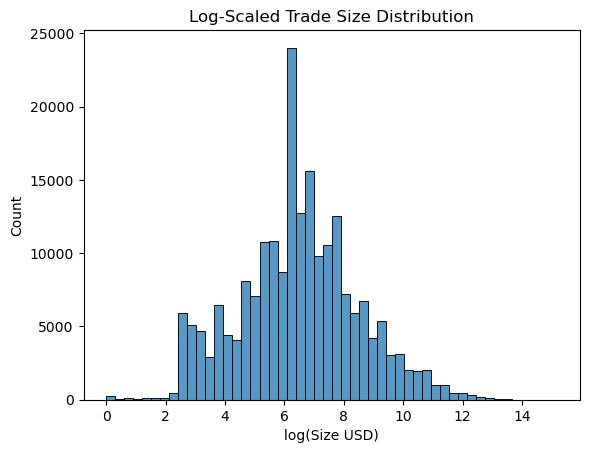

In [31]:
sns.histplot(np.log1p(merged_df['Size USD']), bins=50)
plt.title('Log-Scaled Trade Size Distribution')
plt.xlabel('log(Size USD)')
plt.show()

In [32]:
merged_df['Size USD'].describe()

count    2.112180e+05
mean     5.639192e+03
std      3.657557e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970200e+02
75%      2.058878e+03
max      3.921431e+06
Name: Size USD, dtype: float64

#

#

# Analysis

### 7. Performance between Fear Vs Greed days

In [33]:
def map_sentiment(x):
    if x in ['Fear', 'Extreme Fear']:
        return 'Fear'
    elif x in ['Greed', 'Extreme Greed']:
        return 'Greed'
    else:
        return 'Neutral'

merged_df['sentiment_group'] = merged_df['classification'].apply(map_sentiment)

In [34]:
daily_metrics = merged_df.groupby(['date', 'sentiment_group']).agg(
    daily_pnl=('Net_PnL', 'sum'),
    trades=('Net_PnL', 'count'),
    win_rate=('Net_PnL', lambda x: (x > 0).mean()),
    loss_rate=('Net_PnL', lambda x: (x < 0).mean()),
    avg_trade_size=('Size USD', 'mean')).reset_index()

daily_metrics

,date,sentiment_group,daily_pnl,trades,win_rate,loss_rate,avg_trade_size
0,2023-05-01,Greed,0.000000,3,0.000000,0.000000,159.000000
1,2023-12-05,Greed,-12.501455,9,0.000000,1.000000,5556.203333
2,2023-12-14,Greed,-233.735568,11,0.363636,0.636364,10291.213636
3,2023-12-15,Greed,-27.284523,2,0.000000,1.000000,5304.975000
4,2023-12-16,Greed,-3.837189,3,0.000000,1.000000,5116.256667
...,...,...,...,...,...,...,...
474,2025-04-27,Greed,2646.140695,337,0.353116,0.646884,1446.699377
475,2025-04-28,Neutral,30899.562355,1379,0.416969,0.583031,18944.830667
476,2025-04-29,Greed,120600.318140,2243,0.432011,0.567989,15198.177289
477,2025-04-30,Greed,11053.613496,1113,0.264151,0.734052,11405.102291


In [39]:
sentiment_summary = daily_metrics.groupby('sentiment_group').agg(
    avg_daily_pnl = ('daily_pnl', 'mean'),
    avg_win_rate = ('win_rate', 'mean'),
    avg_loss_frequency = ('loss_rate', 'mean'),
    avg_trades = ('trades', 'mean'),
    avg_trade_size = ('avg_trade_size', 'mean')
).reset_index()

sentiment_summary

,sentiment_group,avg_daily_pnl,avg_win_rate,avg_loss_frequency,avg_trades,avg_trade_size
0,Fear,37904.001024,0.325394,0.609086,792.733333,6199.962861
1,Greed,15554.303668,0.407622,0.585856,294.120521,5872.025677
2,Neutral,18709.647869,0.340190,0.655197,562.477612,7157.527121


#

### 7.1 Profitability Comparison Plot

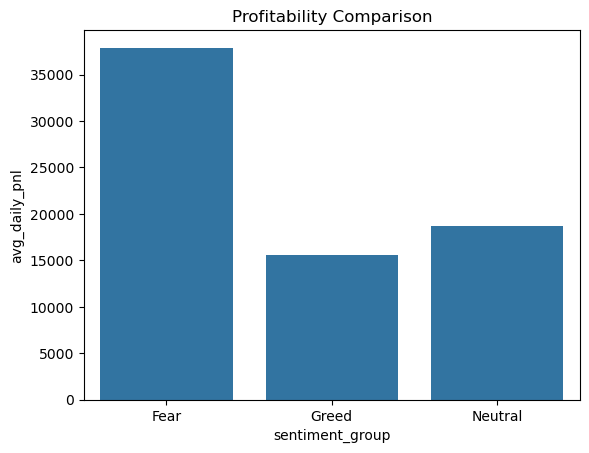

In [36]:
sns.barplot(x='sentiment_group', y='avg_daily_pnl', data=sentiment_summary)
plt.title('Profitability Comparison')
plt.show()

## Insight:

Fear days generate higher average daily profits (37,904) compared to Greed (15,554).

#### Interpretation:
the strategy performs more than twice as well during "Fear" periods than during "Greed" periods.

#

### 7.2 Win Vs Low Comparison

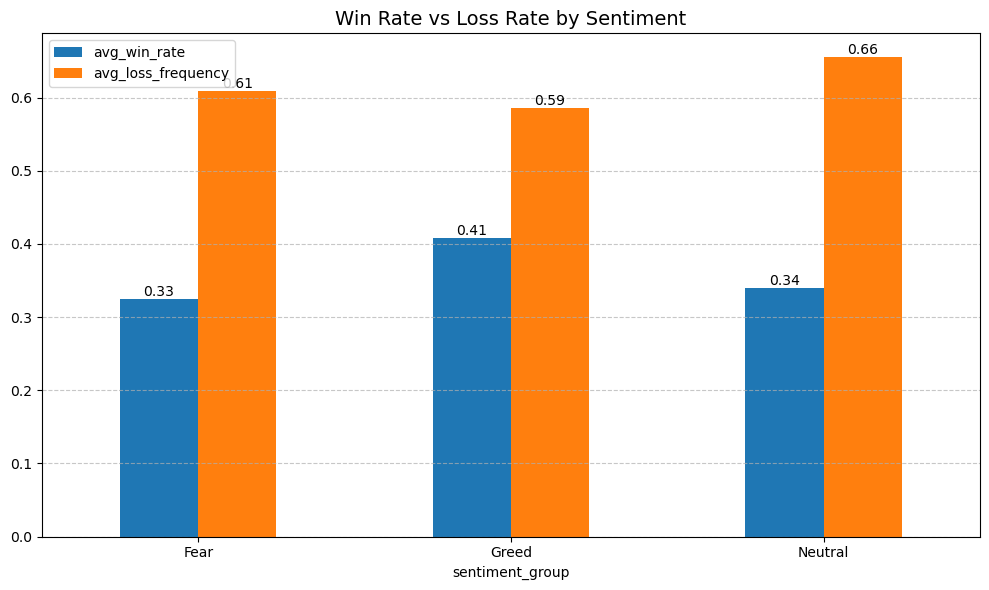

In [41]:
plot_df = sentiment_summary.set_index('sentiment_group')


ax = plot_df[['avg_win_rate', 'avg_loss_frequency']].plot(kind='bar', figsize=(10, 6))

for i in ax.containers:
    ax.bar_label(i, fmt = '%.2f')

plt.title('Win Rate vs Loss Rate by Sentiment', fontsize=14)
plt.xticks(rotation=0)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insight:

Greed days show the highest win rate (40.7%) and lowest loss rate (58.5%), indicating more consistent trading outcomes.

#### Interpretation:
Greed = trend-following behavior
More predictable -> higher consistency


## Insight:
Despite higher profits, Fear days have lower win rates and higher loss frequency, indicating a riskier environment.

#### Interpretation:

- Many losing trades
- Few large winners ->  drives total profit

#

### 7.3 Trading Behavior Plot

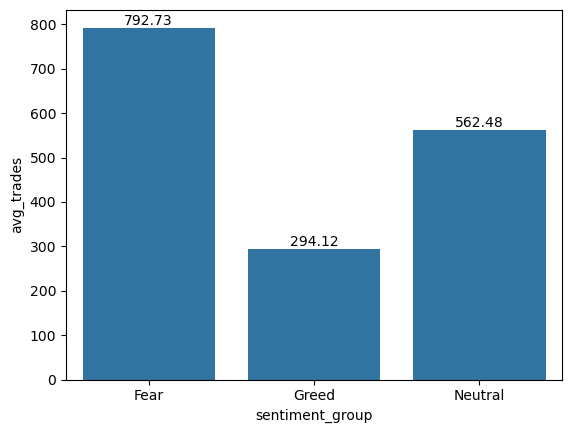

In [42]:
ax = sns.barplot(x='sentiment_group', y='avg_trades', data=sentiment_summary)

for i in ax.containers:
    ax.bar_label(i, fmt = '%.2f')
    
plt.show()

## Insight:

Traders execute significantly more trades during Fear (792 vs 294 in Greed).

#### Interpretation:

- Fear → panic or opportunity-driven trading
- More activity = more volatility

Trader performance varies significantly between Fear and Greed market conditions. Fear days exhibit substantially higher average daily profitability, but with lower win rates and higher loss frequency, indicating a high-risk, high-reward environment. In contrast, Greed days provide more consistent performance with higher win rates and lower loss ratios, though with comparatively lower profitability. Additionally, trading activity is significantly higher during Fear periods, suggesting increased market participation and volatility. Overall, Fear markets favor aggressive strategies, while Greed markets support more stable and consistent trading behavior.

#

#

## 8 Segments

### 8.1 High Vs Low Leverage Traders

In [43]:
threshold = merged_df['Size USD'].median()

merged_df['exposure_segment'] = merged_df['Size USD'].apply(lambda x: 'High Exposure' if x >= threshold else 'Low Exposure')

Since the dataset does not include margin or collateral information, true leverage cannot be computed. Therefore, we use "Size USD" as a proxy for position sizing and exposure intensity. This allows us to analyze risk-taking behavior across different sentiment regimes, even though it does not represent actual financial leverage.

Median was used as the threshold to segment traders into high and low leverage groups because leverage distributions are typically right-skewed in trading datasets. The median provides a robust central tendency measure that is not influenced by extreme outliers such as highly leveraged positions. Additionally, it ensures balanced group sizes, enabling fair and interpretable comparisons of behavioral differences across sentiment regimes.

#

### 8.2 Frequent Vs Infrequent Traders

In [45]:
trade_freq = merged_df.groupby('Account').size().reset_index(name='trade_count')
threshold = trade_freq['trade_count'].median()

merged_df = merged_df.merge(trade_freq, on='Account', how='left')

merged_df['frequency_segment'] = merged_df['trade_count'].apply(lambda x: 'Frequent Trader' if x >= threshold else 'Infrequent Trader')

#

### 8.3 Winners Vs Inconsistent Traders

In [46]:
trader_stats = merged_df.groupby('Account').agg({'Closed PnL': ['mean', 'std', 'count']}).reset_index()

trader_stats.columns = ['Account', 'avg_pnl', 'pnl_std', 'trade_count']

# consistency metric (lower std = more consistent)
consistency_threshold = trader_stats['pnl_std'].median()

trader_stats['consistency_segment'] = trader_stats['pnl_std'].apply(lambda x: 'Consistent Trader' if x <= consistency_threshold else 'Inconsistent Trader')

merged_df = merged_df.merge(trader_stats[['Account','consistency_segment']], on='Account', how='left')

#

### 8.4 Behaviourial analysis under Sentiment

In [47]:
leverage_behavior = merged_df.groupby(['sentiment_group', 'exposure_segment']).agg({
    'Size USD': 'mean',
    'Closed PnL': 'mean',
    'Account': 'count'
}).reset_index().rename(columns={'Account': 'trade_count'})

leverage_behavior

,sentiment_group,exposure_segment,Size USD,Closed PnL,trade_count
0,Fear,High Exposure,12942.390121,87.644683,45457
1,Fear,Low Exposure,251.107027,2.969860,37780
2,Greed,High Exposure,9540.693816,108.031311,42192
3,Greed,Low Exposure,218.421009,6.387200,48103
4,Neutral,High Exposure,9784.017892,69.578672,17962
5,Neutral,Low Exposure,228.226207,2.187618,19724


#

### 8.5 Trading Frequency Behaviour

In [48]:
freq_behavior = merged_df.groupby(['sentiment_group','frequency_segment']).agg({
    'Account': 'count',
    'Size USD': 'mean'
}).reset_index().rename(columns={'Account':'trade_count'})

In [49]:
freq_behavior

,sentiment_group,frequency_segment,trade_count,Size USD
0,Fear,Frequent Trader,72515,7563.359761
1,Fear,Infrequent Trader,10722,4602.874290
2,Greed,Frequent Trader,80505,4643.231399
3,Greed,Infrequent Trader,9790,4008.612410
4,Neutral,Frequent Trader,33937,4780.761654
5,Neutral,Infrequent Trader,3749,4800.574775


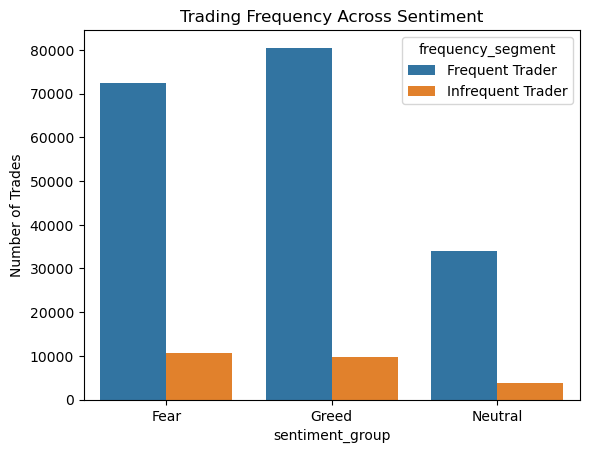

In [50]:
sns.barplot(data=freq_behavior,x='sentiment_group',y='trade_count',hue='frequency_segment')

plt.title("Trading Frequency Across Sentiment")
plt.ylabel("Number of Trades")
plt.show()

## Insight:
- Frequent traders dominate trading activity across all sentiment conditions.
- Trading activity is highest during Fear → shows panic trading or high volatility opportunities.
- Infrequent traders behave more steadily and show less reaction to sentiment changes.

#

### 8.6 Long/Short bias Shift

In [51]:
merged_df['is_long'] = merged_df['Side'].eq('BUY').astype(int)
merged_df['is_short'] = merged_df['Side'].eq('SELL').astype(int)

In [52]:
direction_behavior = merged_df.groupby(['sentiment_group', 'exposure_segment']).agg({'is_long': 'mean', 'is_short': 'mean'}).reset_index()

direction_behavior

,sentiment_group,exposure_segment,is_long,is_short
0,Fear,High Exposure,0.486108,0.513892
1,Fear,Low Exposure,0.505770,0.494230
2,Greed,High Exposure,0.491396,0.508604
3,Greed,Low Exposure,0.452841,0.547159
4,Neutral,High Exposure,0.494099,0.505901
5,Neutral,Low Exposure,0.511762,0.488238


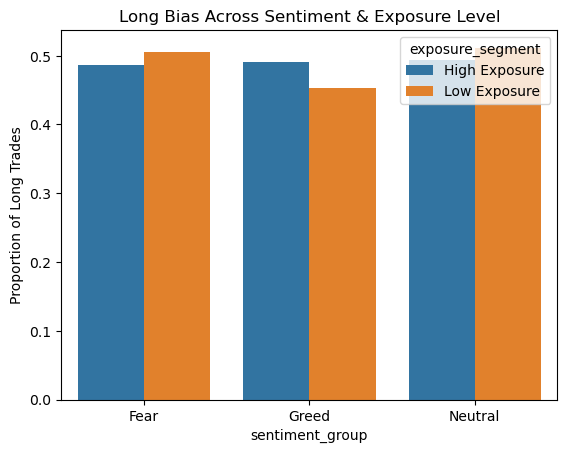

In [53]:
sns.barplot(data=direction_behavior,x='sentiment_group',y='is_long',hue='exposure_segment')

plt.title("Long Bias Across Sentiment & Exposure Level")
plt.ylabel("Proportion of Long Trades")
plt.show()

## Insight:

- During Greed, long bias decreases slightly in high exposure traders -> they take more short trades than expected.
- During Fear, low exposure traders slightly increase long positions -> possibly buying dips cautiously.
- Overall long/short split is close to 50/50 -> market is highly two-sided, not strongly directional.
- Neutral sentiment shows almost balanced behavior -> no strong directional conviction.

#

### 8.7 Position Size Vs Sentiment

In [54]:
position_behavior = merged_df.groupby('sentiment_group').agg(
    avg_position_size=('Size USD', 'mean'),
    median_position_size=('Size USD', 'median'),
    trade_count=('Size USD', 'count')).reset_index()

print(position_behavior)

  sentiment_group  avg_position_size  median_position_size  trade_count
0            Fear        7182.011019               749.400        83237
1           Greed        4574.424490               552.200        90295
2         Neutral        4782.732661               547.655        37686


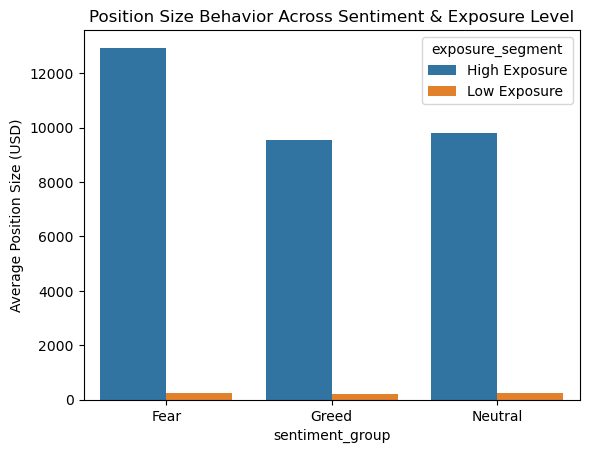

In [55]:
sns.barplot(data=leverage_behavior,x='sentiment_group',y='Size USD',hue='exposure_segment')

plt.title("Position Size Behavior Across Sentiment & Exposure Level")
plt.ylabel("Average Position Size (USD)")
plt.show()

## Insight:
- High exposure traders always take much larger positions than low exposure traders across all sentiment types
- Position sizes are highest during Fear and Greed for high exposure traders -> shows traders become aggressive in both volatile and bullish markets
- Low exposure traders remain stable (200–250 USD range) -> they behave consistently regardless of sentiment.

#

## Summary:

#### Position Size Behavior: 

- Traders increase position sizes significantly during Fear and Greed periods, especially high exposure traders
- Low exposure traders remain stable, showing consistent risk behavior regardless of sentiment

#### Trading Frequency Behavior:

- Frequent traders dominate activity across all sentiment regimes
- Trading activity peaks during Fear, suggesting higher market volatility leads to more aggressive trading behavior

#### Long/Short Bias Behavior:

- Traders show a relatively balanced long/short distribution across all sentiment conditions
- However, slight shifts are observed:
     - Greed periods show a mild increase in short positions among high exposure traders, while Fear periods show slightly more long positions among cautious traders.

#

#

# Recommendation:

## Strategy1: Risk control for high exposure traders:

During Fear and Greed market conditions, traders who usually place big trades tend to take even bigger risks, So the simple rule is: When the market is very fearful or very greedy, reduce the size of big trades.

because
- In Fear -> people panic and trade aggressively
- In Greed -> people become overconfident
- In both cases -> big trades can lead to big losses


##### Simple strategy:

In Fear and Greed markets, limit how much money high-risk traders can put into a single trade. This helps avoid large losses caused by emotional decisions.

#

## Strategy 2: Control overtrading in Greed markets

Noticed that traders do a lot more trading during Fear, and also stay active during Greed. But too many trades in Greed often leads to poor decisions.

because

- Fear ->  many trades because of panic or opportunity
- Greed -> traders overtrade because they expect prices to keep rising


##### Simple strategy:

Allow more trading during Fear because opportunities are high but reduce unnecessary trading during Greed to avoid emotional or overconfident decisions.

#

#

# Model Building

In [56]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,Net_PnL,sentiment_group,exposure_segment,trade_count,frequency_segment,consistency_segment,is_long,is_short
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,895000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,-0.345404,Greed,High Exposure,563,Infrequent Trader,Consistent Trader,1,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,443000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,-0.005600,Greed,Low Exposure,563,Infrequent Trader,Consistent Trader,1,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,660000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,-0.050431,Greed,High Exposure,563,Infrequent Trader,Consistent Trader,1,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1080000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,-0.050043,Greed,High Exposure,563,Infrequent Trader,Consistent Trader,1,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1050000000000000,1970-01-01 00:28:50,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed,-0.003055,Greed,Low Exposure,563,Infrequent Trader,Consistent Trader,1,0


In [57]:
# Target VAriable

merged_df['profit_label'] = (merged_df['Closed PnL'] > 0).astype(int)

# 1 as Profit
# 0 as Loss

In [58]:
merged_df['profit_label'].value_counts()

profit_label
0    124355
1     86863
Name: count, dtype: int64

In [59]:
# Independent Variables

features = merged_df[['Size USD','is_long','is_short']]

features = pd.concat([features,pd.get_dummies(merged_df['sentiment_group'])], axis=1)

#

# Training Model

In [60]:
x = features
y = merged_df['profit_label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [61]:
pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6548859009563488


#

# Clustering Traders into Behavioral Archetypes
Group traders based on behavior instead of labeling them manually

In [62]:
trader_profile = merged_df.groupby('Account').agg({'Size USD': 'mean','Closed PnL': 'mean','is_long': 'mean'}).reset_index()

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_profile[['Size USD', 'Closed PnL', 'is_long']])

In [64]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_profile['cluster'] = kmeans.fit_predict(X_scaled)

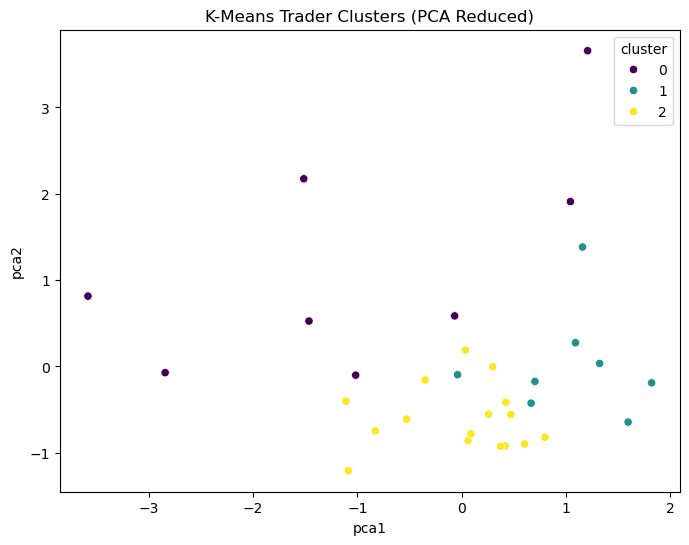

In [65]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

trader_profile['pca1'] = components[:, 0]
trader_profile['pca2'] = components[:, 1]

plt.figure(figsize=(8,6))

sns.scatterplot(data=trader_profile,x='pca1',y='pca2',hue='cluster',palette='viridis')

plt.title("K-Means Trader Clusters (PCA Reduced)")
plt.show()

In [66]:
merged_df.sample(20000).to_csv("merged_sample.csv", index=False)

#

#

# Final Summary:

In this project, we analyzed how market sentiment (Fear, Greed, Neutral) impacts trader performance and behavior using real trading data.

From the analysis, we observed that market sentiment significantly influences trader decisions. During Fear periods, traders tend to trade more frequently and take larger positions, leading to higher overall profits but lower win rates, indicating a high-risk, high-reward environment. In contrast, Greed periods show more consistent performance with relatively stable trading behavior

Behavioral analysis revealed that traders adjust their risk-taking more than their trade direction. Position sizes and trading activity increase during extreme sentiment conditions, while long/short bias remains relatively balanced across all regimes

A simple predictive model was built to estimate trade profitability using sentiment and behavioral features. The results indicate that while sentiment and trade characteristics provide some predictive power, trading outcomes are still influenced by market uncertainty

Additionally, clustering analysis grouped traders into different behavioral types based on their trading patterns, such as high-risk traders, low-risk traders, and directional traders. This highlights that traders do not behave uniformly and follow distinct strategies

Overall, the study shows that market sentiment plays a crucial role in shaping trading behavior, especially in terms of risk exposure and activity levels. Effective trading strategies should focus on controlling risk and avoiding emotional decision-making during extreme market conditions.

#